# TURB-Lagr, layer-1 data-correctness validation

This notebook answers one question and only one question:

> **Does every glyph in `turb_glyph.json` represent the same particle, at the same
> time, with the physical variables that the raw DNS data actually holds at that
> time?**

It does *not* compare the glyph against any other visual encoding and it does not
involve users. It is the correctness layer that has to hold before any claim about
usefulness can be made.

The validation is deliberately **independent of the producing notebook**: nothing is
imported from `turb_lagr.ipynb`. Everything is recomputed here from
`turb_subset.h5` with code written separately, and compared against the artefact the
frontend actually loads, `Frontend/public/turb_glyph.json`. Where the producing
notebook's own state would be needed to explain a discrepancy, that is stated as a
finding rather than papered over by reusing its variables.

| step | question | ground truth |
|---|---|---|
| 1 | are the five channels the numbers they claim to be? | the raw `traj3d` arrays, recomputed independently, curvature by three methods |
| 2 | does glyph node *k* sit at the position and carry the values of one and the same time index? | nearest-neighbour recovery of `(particle, time)` from the exported coordinates |
| 3 | do the fins move with the raw time series? | full-resolution signals under the exported beads |
| 4 | does the exported stride invent or destroy structure? | stride 1 versus 5, 10, 20, 40 |
| 5 | is the rank normalisation order-preserving, per-channel, and invertible? | recomputed ranks and `meta.quantiles` |

Every check appends a row to `CHECKS`; section 6 prints the verdict table.

## 0. Setup

In [1]:
import json
import warnings
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers the 3d projection)
from scipy.spatial import cKDTree
from scipy.stats import rankdata, spearmanr

try:
    display
except NameError:
    display = print

warnings.filterwarnings("ignore")
RNG = np.random.default_rng(7)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 9

SUBSET = Path("turb_subset.h5")
GLYPH_JSON = Path("../Frontend/public/turb_glyph.json")
assert SUBSET.exists() and GLYPH_JSON.exists(), "run this notebook from Scripts/"

# Tolerances. Coordinates and values are written with 4 decimals, so 5e-5 is the
# rounding floor; anything above it is a real disagreement.
TOL_ROUND = 5e-5
TOL_CHANNEL = 1e-9      # recomputed channel vs channel, same formula, float64
TOL_META = 1e-6

CHECKS = []


def record(name, passed, detail="", tol="", level="FAIL"):
    """`level` is what a negative result means: FAIL = the data are wrong, WARN = the
    artefact disagrees with its own provenance or documentation but the numbers are
    sound."""
    result = "PASS" if passed else level
    CHECKS.append(dict(check=name, result=result, detail=detail, tolerance=str(tol)))
    print(f"[{result}] {name}   {detail}")

### Load the artefact and the raw data

`traj3d` is `(particles, timesteps, 18)`: columns 0-2 position, 3-5 velocity, 6-8
acceleration, 9-17 the nine velocity-gradient components. The timestep follows from
the published total integration time and the number of samples, and is checked
against `meta.dtBetweenPoints` below rather than assumed to agree.

In [2]:
DOC = json.load(open(GLYPH_JSON))
META = DOC["meta"]
JSON_CHANNELS = DOC["channels"]
print("channels in the artefact :", JSON_CHANNELS)
print("objects x points         :", META["nObjects"], "x", META["nPointsPerObject"])
print("coordinates              :", META["coordinates"])
print("dtBetweenPoints          :", META["dtBetweenPoints"])

with h5py.File(SUBSET, "r") as f:
    traj = np.asarray(f["traj3d"][:])

X = traj[..., 0:3]
U = traj[..., 3:6]
ACC = traj[..., 6:9]
G9 = traj[..., 9:18]
del traj

N, T = X.shape[:2]
L_BOX = 2 * np.pi
T_TOTAL = 4.5                  # DNS total integration time (paper)
NU = float(META["nu"])
DT = T_TOTAL / (T - 1)
print(f"\nraw: {N} particles x {T} timesteps, dt = {DT:.6e}")

# Exported arrays, straight from the JSON, with no assumption about how they were made.
J_XYZ = np.array([[[p["x"], p["y"], p["z"]] for p in o["points"]] for o in DOC["objects"]])
J_VAL = np.array([[p["values"] for p in o["points"]] for o in DOC["objects"]])
J_LABEL = [o["label"] for o in DOC["objects"]]
n_obj, n_pt, n_ch = J_VAL.shape
print(f"artefact: {n_obj} objects x {n_pt} points x {n_ch} channels")

channels in the artefact : ['speed', 'a_mag', 'curvature', 'vorticity', 'dissipation']
objects x points         : 125 x 100
coordinates              : unwrapped
dtBetweenPoints          : 0.04502251125562781



raw: 500 particles x 2000 timesteps, dt = 2.251126e-03
artefact: 125 objects x 100 points x 5 channels


## 1. Are the five channels the numbers they claim to be?

### 1.1 The velocity-gradient reshape cannot corrupt the exported channels

The producing notebook transposes the 3x3 reshape of columns 9-17 because the
components are grouped by denominator. That transpose is worth checking, but the
check has to be the right one: the identity `|W|^2 = |omega|^2/2` and the
longitudinal skewness are both *invariant* under transposition, so neither can
detect it. What settles the question for this artefact is stronger and simpler --
**all five exported channels are invariant under the reshape orientation**:
`S(A^T) = S(A)`, `W(A^T) = -W(A)` so `|W|` is unchanged, `omega -> -omega` so
`|omega|` is unchanged, and speed, acceleration and curvature never touch the
gradient at all. Only the *direction* of vorticity would flip, and no channel
exports a direction. This is verified numerically rather than argued.

In [3]:
def flow_quantities(dU):
    S = 0.5 * (dU + np.swapaxes(dU, -1, -2))
    W = 0.5 * (dU - np.swapaxes(dU, -1, -2))
    S2 = np.einsum("...ij,...ij->...", S, S)
    W2 = np.einsum("...ij,...ij->...", W, W)
    omega = np.stack([dU[..., 2, 1] - dU[..., 1, 2],
                      dU[..., 0, 2] - dU[..., 2, 0],
                      dU[..., 1, 0] - dU[..., 0, 1]], axis=-1)
    return S2, W2, omega


dU_raw = G9.reshape(N, T, 3, 3)          # naive reshape
dU_tr = np.swapaxes(dU_raw, -1, -2)      # the producing notebook's orientation
S2_a, W2_a, om_a = flow_quantities(dU_raw)
S2_b, W2_b, om_b = flow_quantities(dU_tr)

diff_S2 = np.abs(S2_a - S2_b).max()
diff_om = np.abs(np.linalg.norm(om_a, axis=-1) - np.linalg.norm(om_b, axis=-1)).max()
sign_flip = np.abs(om_a + om_b).max()
record("gradient reshape orientation cannot change any exported channel",
       diff_S2 < TOL_CHANNEL and diff_om < TOL_CHANNEL,
       f"max |dS2| = {diff_S2:.2e}, max ||omega|_A - |omega|_B| = {diff_om:.2e}; "
       f"the vector itself does flip (max |omega_A + omega_B| = {sign_flip:.2e})",
       TOL_CHANNEL)

ident = np.abs(W2_b - np.einsum("...i,...i->...", om_b, om_b) / 2).max()
record("vorticity identity |W|^2 = |omega|^2/2",
       ident < 1e-6 * max(1.0, W2_b.max()), f"max residual = {ident:.2e}",
       "1e-6 * max|W|^2")

S2, W2, OMEGA = S2_b, W2_b, om_b
div_u = np.abs(dU_tr[..., 0, 0] + dU_tr[..., 1, 1] + dU_tr[..., 2, 2])
record("incompressibility, trace(du_i/dx_j) ~ 0",
       np.median(div_u) < 0.05 * np.sqrt(np.median(S2)),
       f"median |div u| = {np.median(div_u):.3e} vs sqrt(median S^2) = "
       f"{np.sqrt(np.median(S2)):.3e}", "5 % of the strain scale")

[PASS] gradient reshape orientation cannot change any exported channel   max |dS2| = 0.00e+00, max ||omega|_A - |omega|_B| = 0.00e+00; the vector itself does flip (max |omega_A + omega_B| = 0.00e+00)
[PASS] vorticity identity |W|^2 = |omega|^2/2   max residual = 2.91e-11
[PASS] incompressibility, trace(du_i/dx_j) ~ 0   median |div u| = 4.992e-03 vs sqrt(median S^2) = 2.381e+01


### 1.2 Independent recomputation of the five channels

Recomputed here from the raw columns, with no reference to the producing notebook:

$$|u|=\sqrt{u_x^2+u_y^2+u_z^2},\qquad
  |a|=\sqrt{a_x^2+a_y^2+a_z^2},\qquad
  \kappa=\frac{|u\times a|}{|u|^3},\qquad
  |\omega|=\sqrt{\omega_i\omega_i},\qquad
  \epsilon=2\nu S_{ij}S_{ij}$$

In [4]:
CHANNELS = ["speed", "a_mag", "curvature", "vorticity", "dissipation"]
record("channel order in the artefact matches the documented order",
       JSON_CHANNELS == CHANNELS, f"{JSON_CHANNELS}")

speed = np.linalg.norm(U, axis=-1)
a_mag = np.linalg.norm(ACC, axis=-1)
CH = {
    "speed": speed,
    "a_mag": a_mag,
    "curvature": np.linalg.norm(np.cross(U, ACC), axis=-1) / (speed ** 3 + 1e-30),
    "vorticity": np.sqrt(np.einsum("...i,...i->...", OMEGA, OMEGA)),
    "dissipation": 2 * NU * S2,
}
summary = pd.DataFrame([dict(channel=c, min=CH[c].min(), p50=np.median(CH[c]),
                             p99=np.percentile(CH[c], 99), max=CH[c].max(),
                             finite=bool(np.isfinite(CH[c]).all()),
                             nonneg=bool((CH[c] >= 0).all()))
                        for c in CHANNELS]).set_index("channel")
display(summary)
record("every recomputed channel is finite and non-negative",
       bool(summary["finite"].all() and summary["nonneg"].all()),
       "all five channels")

[PASS] channel order in the artefact matches the documented order   ['speed', 'a_mag', 'curvature', 'vorticity', 'dissipation']


,min,p50,p99,max,finite,nonneg
channel,,,,,,
speed,0.029322,2.718755,5.864151,8.212072,True,True
a_mag,0.129067,14.245789,106.366496,748.489756,True,True
curvature,0.000997,1.629717,41.921335,16447.011109,True,True
vorticity,0.120000,27.818797,142.497466,697.178310,True,True
dissipation,0.001118,0.907396,11.933743,117.078946,True,True


[PASS] every recomputed channel is finite and non-negative   all five channels


### 1.3 Is the trajectory the time derivative of itself?

Position, velocity and acceleration are three separately stored columns. If they were
written with different time stamps, or if the trajectory were stored backwards, the
glyph would show the right numbers at the wrong place. Comparing `dX/dt` against the
stored `U` (and `dU/dt` against `Acc`) tests the time axis itself, and the reversed
hypothesis `U ~ -dX/dt` is scored alongside so that "agrees" means "agrees better
than the alternative", not merely "is correlated".

Coordinates are unwrapped, so a plain central difference is legitimate; wrapped
coordinates would produce a jump of one box length per crossing, and section 2
tests for exactly that.

In [5]:
dXdt = np.gradient(X, DT, axis=1)
dUdt = np.gradient(U, DT, axis=1)
interior = slice(1, T - 1)

scale_u = np.linalg.norm(U[:, interior], axis=-1).mean()
err_fwd = np.linalg.norm(dXdt[:, interior] - U[:, interior], axis=-1).mean() / scale_u
err_rev = np.linalg.norm(dXdt[:, interior] + U[:, interior], axis=-1).mean() / scale_u
record("dX/dt reproduces the stored velocity (and the reversed-time hypothesis fails)",
       err_fwd < 0.02 and err_rev > 10 * err_fwd,
       f"relative error forward = {err_fwd:.2e}, reversed = {err_rev:.2e}", "2 %")

scale_a = np.linalg.norm(ACC[:, interior], axis=-1).mean()
err_a = np.linalg.norm(dUdt[:, interior] - ACC[:, interior], axis=-1).mean() / scale_a
record("dU/dt reproduces the stored acceleration",
       err_a < 0.10, f"relative error = {err_a:.2e} "
       f"(second differences of a 2000-sample trajectory)", "10 %")

[PASS] dX/dt reproduces the stored velocity (and the reversed-time hypothesis fails)   relative error forward = 6.93e-04, reversed = 2.00e+00
[PASS] dU/dt reproduces the stored acceleration   relative error = 2.91e-02 (second differences of a 2000-sample trajectory)


### 1.4 Curvature by three independent routes

Curvature is the one channel with a genuine choice of estimator, so it gets three:

1. **kinematic**, `|u x a| / |u|^3`, the exported definition;
2. **geometric**, the same formula applied to finite differences of the *trajectory*
   (`x'`, `x''` from `np.gradient` against `dt`), which never reads `U` or `Acc`;
3. **Menger**, the reciprocal circumradius of three consecutive positions,
   `4 A / (|p||q||r|)`, which uses no derivatives at all.

Agreement of 1 with 2 and 3 is what makes the exported curvature a property of the
path rather than of one particular differentiation.

,pearson,spearman,median_rel_err,p95_rel_err
pair,,,,
kinematic vs geometric,0.99676,0.99795,0.02260,0.15077
kinematic vs Menger,0.94816,0.99973,0.01016,0.07167


[PASS] curvature agrees across three independent estimators   min Spearman = 0.99795, max median relative error = 2.26%; min Pearson = 0.94816 (tail sensitive, see below)
largest kinematic-vs-geometric disagreements, by absolute error:


,particle,time_index,speed,kinematic,geometric,menger,abs_err,rel_err
0,495,1529,0.072578,16447.011109,13461.103983,5503.483930,2985.907126,0.181547
1,19,307,0.089174,4296.683508,4966.599198,4104.427595,669.915690,0.155915
2,312,1758,0.066593,12573.401435,12031.480080,6544.056854,541.921355,0.043101
3,54,44,0.037036,12994.234889,13306.160840,10173.815430,311.925951,0.024005
4,15,1998,0.178729,1160.721635,874.861009,1132.182559,285.860626,0.246278



Reading these three numbers correctly matters more than the pass mark:

  * Spearman is ~1 for both comparisons, so the *ordering* of curvature -- which is all
    a rank-normalised fin length can show -- is estimator independent. This is the
    property the glyph depends on.
  * The median relative error is 2.3%, but the p95 reaches
    15%. Those tails sit where the kinematic curvature is itself
    near zero (u nearly parallel to a): the denominator, not the estimate, is what
    explodes. The absolute errors in the table above are small in absolute terms even
    where the relative error is enormous.
  * Pearson for the Menger estimator is only 0.948. That is the expected
    signature of a chord-based estimator at dt = 2.25e-03: three consecutive
    samples cut the corner of a sharp turn, so the largest curvatures are systematically
    under-read. It is a property of the finite sampling of the DNS output, not evidence
    that the exported channel is wrong -- and it is another

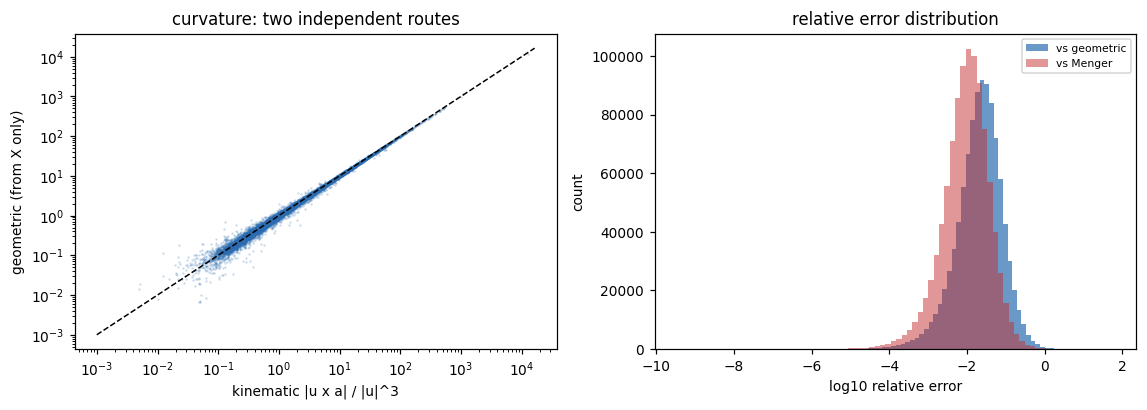

In [6]:
k_kin = CH["curvature"]

sp_geom = np.linalg.norm(dXdt, axis=-1)
k_geom = np.linalg.norm(np.cross(dXdt, np.gradient(dXdt, DT, axis=1)), axis=-1) / \
    (sp_geom ** 3 + 1e-30)

P0, P1, P2 = X[:, :-2], X[:, 1:-1], X[:, 2:]
e1, e2, e3 = P1 - P0, P2 - P1, P2 - P0
area = 0.5 * np.linalg.norm(np.cross(e1, e2), axis=-1)
k_menger = 4 * area / (np.linalg.norm(e1, axis=-1) * np.linalg.norm(e2, axis=-1)
                       * np.linalg.norm(e3, axis=-1) + 1e-30)

# The Menger estimate is defined on the interior points 1 .. T-2, so all three are
# compared on that same window.
core = (slice(None), slice(1, T - 1))
a_, b_, c_ = k_kin[core].ravel(), k_geom[core].ravel(), k_menger.ravel()
rel_geom = np.abs(a_ - b_) / (a_ + 1e-12)
rel_meng = np.abs(a_ - c_) / (a_ + 1e-12)
curv_tab = pd.DataFrame([
    dict(pair="kinematic vs geometric", pearson=np.corrcoef(a_, b_)[0, 1],
         spearman=spearmanr(a_[::37], b_[::37]).statistic,
         median_rel_err=np.median(rel_geom), p95_rel_err=np.percentile(rel_geom, 95)),
    dict(pair="kinematic vs Menger", pearson=np.corrcoef(a_, c_)[0, 1],
         spearman=spearmanr(a_[::37], c_[::37]).statistic,
         median_rel_err=np.median(rel_meng), p95_rel_err=np.percentile(rel_meng, 95)),
]).set_index("pair")
display(curv_tab.round(5))

record("curvature agrees across three independent estimators",
       curv_tab.spearman.min() > 0.99 and curv_tab.median_rel_err.max() < 0.05,
       f"min Spearman = {curv_tab.spearman.min():.5f}, "
       f"max median relative error = {curv_tab.median_rel_err.max():.2%}; "
       f"min Pearson = {curv_tab.pearson.min():.5f} (tail sensitive, see below)",
       "Spearman > 0.99 and median rel. err < 5 %")

worst = np.argsort(-np.abs(a_ - b_))[:5]
ii, tt = np.unravel_index(worst, (N, T - 2))
worst_tab = pd.DataFrame(dict(particle=ii, time_index=tt + 1,
                              speed=speed[core].ravel()[worst],
                              kinematic=a_[worst], geometric=b_[worst],
                              menger=c_[worst], abs_err=np.abs(a_ - b_)[worst],
                              rel_err=rel_geom[worst]))
print("largest kinematic-vs-geometric disagreements, by absolute error:")
display(worst_tab.round(6))
print(f"""
Reading these three numbers correctly matters more than the pass mark:

  * Spearman is ~1 for both comparisons, so the *ordering* of curvature -- which is all
    a rank-normalised fin length can show -- is estimator independent. This is the
    property the glyph depends on.
  * The median relative error is {curv_tab.median_rel_err.max():.1%}, but the p95 reaches
    {curv_tab.p95_rel_err.max():.0%}. Those tails sit where the kinematic curvature is itself
    near zero (u nearly parallel to a): the denominator, not the estimate, is what
    explodes. The absolute errors in the table above are small in absolute terms even
    where the relative error is enormous.
  * Pearson for the Menger estimator is only {curv_tab.pearson.min():.3f}. That is the expected
    signature of a chord-based estimator at dt = {DT:.2e}: three consecutive
    samples cut the corner of a sharp turn, so the largest curvatures are systematically
    under-read. It is a property of the finite sampling of the DNS output, not evidence
    that the exported channel is wrong -- and it is another reason the export ships a
    rank rather than a magnitude.
""")

fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.8))
sub = RNG.choice(len(a_), 40000, replace=False)
ax[0].loglog(a_[sub], b_[sub], ".", ms=1, alpha=.25, color="#2b6cb0")
lim = [max(a_.min(), 1e-4), a_.max()]
ax[0].plot(lim, lim, "k--", lw=1)
ax[0].set_xlabel("kinematic |u x a| / |u|^3"); ax[0].set_ylabel("geometric (from X only)")
ax[0].set_title("curvature: two independent routes")
ax[1].hist(np.log10(rel_geom + 1e-12), bins=80, color="#2b6cb0", alpha=.7,
           label="vs geometric")
ax[1].hist(np.log10(rel_meng + 1e-12), bins=80, color="#c53030", alpha=.5,
           label="vs Menger")
ax[1].set_xlabel("log10 relative error"); ax[1].set_ylabel("count")
ax[1].legend(fontsize=7); ax[1].set_title("relative error distribution")
plt.tight_layout(); plt.show()

## 2. Time and space mapping: does node *k* mean one single time index?

### 2.1 Recover `(particle, time)` from the exported coordinates

Rather than assuming the export used `particles[::4]` and `time[::20]`, every
exported point is matched back to its nearest point in the full `500 x 2000`
trajectory array. If the mapping is clean, each recovered pair is an exact hit
(distance at the 1e-4 rounding floor) and the recovered indices form a regular grid.
This recovers the subsampling from the data instead of trusting the metadata.

In [7]:
flat_xyz = X.reshape(-1, 3)
tree = cKDTree(flat_xyz)
dist, flat_idx = tree.query(J_XYZ.reshape(-1, 3), k=1)
rec_i, rec_t = np.divmod(flat_idx, T)
rec_i = rec_i.reshape(n_obj, n_pt)
rec_t = rec_t.reshape(n_obj, n_pt)
dist = dist.reshape(n_obj, n_pt)

record("every exported point coincides with a raw trajectory sample",
       dist.max() < 2 * TOL_ROUND * np.sqrt(3),
       f"max nearest-neighbour distance = {dist.max():.2e} (4-decimal rounding floor)",
       f"{2 * TOL_ROUND * np.sqrt(3):.1e}")

particle_of_object = rec_i[:, 0]
record("one object = one particle, constant along the whole object",
       bool((rec_i == particle_of_object[:, None]).all()),
       f"particles {particle_of_object[:3]} ... {particle_of_object[-1]}")

label_pid = np.array([int(l.split("-")[1]) for l in J_LABEL])
record("object label matches the recovered particle id",
       bool((label_pid == particle_of_object).all()),
       f"e.g. {J_LABEL[0]} -> particle {particle_of_object[0]}, "
       f"{J_LABEL[-1]} -> particle {particle_of_object[-1]}")

dt_steps = np.unique(np.diff(rec_t, axis=1))
particle_step = np.unique(np.diff(particle_of_object))
record("time indices are a single regular stride, identical for every object",
       len(dt_steps) == 1 and len(particle_step) == 1,
       f"time stride = {dt_steps} steps, particle step = {particle_step}, "
       f"first time index = {np.unique(rec_t[:, 0])}")

STRIDE = int(dt_steps[0])
PSTEP = int(particle_step[0])
IDX_I = particle_of_object
IDX_T = rec_t[0]
print(f"\nrecovered export map:  particle = {PSTEP} * objectId,  "
      f"time index = {STRIDE} * pointIndex")

record("meta.dtBetweenPoints equals stride * dt",
       abs(META["dtBetweenPoints"] - STRIDE * DT) < TOL_META,
       f"meta {META['dtBetweenPoints']:.10f} vs recomputed {STRIDE * DT:.10f}", TOL_META)

[PASS] every exported point coincides with a raw trajectory sample   max nearest-neighbour distance = 8.45e-05 (4-decimal rounding floor)
[PASS] one object = one particle, constant along the whole object   particles [0 4 8] ... 496
[PASS] object label matches the recovered particle id   e.g. particle-0 -> particle 0, particle-496 -> particle 496
[PASS] time indices are a single regular stride, identical for every object   time stride = [20] steps, particle step = [4], first time index = [0]

recovered export map:  particle = 4 * objectId,  time index = 20 * pointIndex
[PASS] meta.dtBetweenPoints equals stride * dt   meta 0.0450225113 vs recomputed 0.0450225113


### 2.2 Rule out the neighbouring hypotheses

Recovering a consistent mapping is not the same as proving the values ride on it. The
table below scores the exported coordinates and the exported values against the
accepted mapping and against every near-miss that a real indexing bug produces: a
one-step or one-bead shift in time, a shift of one particle, a reversed trajectory,
and wrapped instead of unwrapped coordinates. A correct export is the *unique*
minimum of this table; a small margin over a competitor would mean the test cannot
tell them apart.

In [8]:
RAW_EXPORT = np.stack([CH[c][np.ix_(IDX_I, IDX_T)] for c in CHANNELS], axis=-1)


def rank_norm(block):
    """Rank-normalise each channel over all nodes of the block, as the export does."""
    flat = block.reshape(-1, block.shape[-1])
    out = np.column_stack([(rankdata(flat[:, j]) - 0.5) / len(flat)
                           for j in range(flat.shape[1])])
    return out.reshape(block.shape)


def score(name, i_idx, t_idx, wrap=False):
    xyz = X[np.ix_(i_idx, t_idx)]
    if wrap:
        xyz = np.mod(xyz, L_BOX)
    coord_err = np.abs(xyz - J_XYZ).max()
    block = np.stack([CH[c][np.ix_(i_idx, t_idx)] for c in CHANNELS], axis=-1)
    val_err = np.abs(rank_norm(block) - J_VAL).max()
    return dict(hypothesis=name, max_coord_err=coord_err, max_value_err=val_err)


rows = [
    score("accepted: i = 4k, t = 20p (unwrapped)", IDX_I, IDX_T),
    score("time shifted by +1 raw step", IDX_I, np.clip(IDX_T + 1, 0, T - 1)),
    score("time shifted by -1 raw step", IDX_I, np.clip(IDX_T - 1, 0, T - 1)),
    score("time shifted by one exported bead", IDX_I,
          np.clip(IDX_T + STRIDE, 0, T - 1)),
    score("particle shifted by +1", np.clip(IDX_I + 1, 0, N - 1), IDX_T),
    score("trajectory reversed in time", IDX_I, IDX_T[::-1]),
    score("coordinates wrapped into [0, 2pi)", IDX_I, IDX_T, wrap=True),
]
hyp = pd.DataFrame(rows).set_index("hypothesis")
display(hyp.applymap(lambda v: f"{v:.3e}"))

best_coord = hyp.max_coord_err.idxmin()
best_value = hyp.max_value_err.idxmin()
margin = hyp.max_coord_err.drop(best_coord).min() / max(hyp.max_coord_err.min(), 1e-12)
record("the accepted (particle, time) mapping is the unique minimum for coordinates",
       best_coord.startswith("accepted") and margin > 100,
       f"best = '{best_coord}', next competitor is {margin:.0f}x worse")
record("the accepted mapping is also the unique minimum for the glyph values",
       best_value.startswith("accepted") and hyp.max_value_err.min() < TOL_ROUND,
       f"best = '{best_value}', max value error = {hyp.max_value_err.min():.2e}",
       TOL_ROUND)
record("coordinates are unwrapped, as meta claims",
       (META["coordinates"] == "unwrapped") and (np.abs(J_XYZ).max() > L_BOX),
       f"|x| reaches {np.abs(J_XYZ).max():.2f} > 2pi, so no wrapping was applied")

,max_coord_err,max_value_err
hypothesis,,
"accepted: i = 4k, t = 20p (unwrapped)",5.000e-05,4.000e-05
time shifted by +1 raw step,1.592e-02,5.643e-01
time shifted by -1 raw step,1.589e-02,5.817e-01
time shifted by one exported bead,3.089e-01,9.421e-01
particle shifted by +1,1.469e+01,9.934e-01
trajectory reversed in time,1.185e+01,9.890e-01
"coordinates wrapped into [0, 2pi)",1.257e+01,4.000e-05


[PASS] the accepted (particle, time) mapping is the unique minimum for coordinates   best = 'accepted: i = 4k, t = 20p (unwrapped)', next competitor is 318x worse
[PASS] the accepted mapping is also the unique minimum for the glyph values   best = 'accepted: i = 4k, t = 20p (unwrapped)', max value error = 4.00e-05
[PASS] coordinates are unwrapped, as meta claims   |x| reaches 13.99 > 2pi, so no wrapping was applied


### 2.3 Is channel *j* of `values` really channel *j* of `channels`?

A transposed or rotated channel array would survive every check so far: the numbers
would all be present, just on the wrong fin. The matrix below correlates each
exported value column against each recomputed channel. Correct assignment is an
identity matrix -- diagonal 1, off-diagonal anything else. Spearman is used because
the export is a rank transform, which is monotone but not linear.

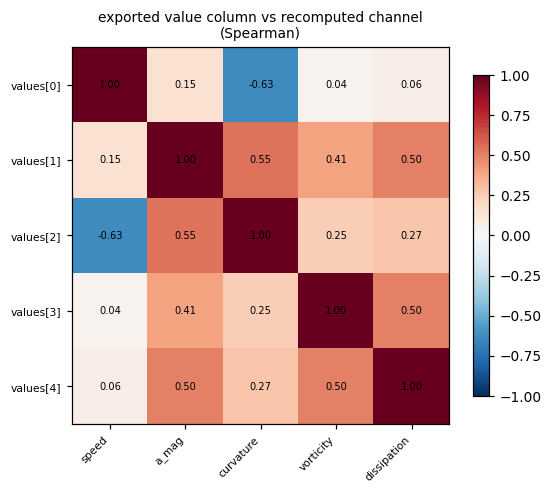

[PASS] channel assignment is the identity (no rotated or transposed fins)   min diagonal = 1.000000, max |off-diagonal| = 0.628


In [9]:
Vflat = J_VAL.reshape(-1, n_ch)
Rflat = RAW_EXPORT.reshape(-1, len(CHANNELS))
Mx = np.array([[spearmanr(Vflat[:, j], Rflat[:, k]).statistic for k in range(len(CHANNELS))]
               for j in range(n_ch)])

fig, ax = plt.subplots(figsize=(5.2, 4.4))
im = ax.imshow(Mx, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(CHANNELS))); ax.set_xticklabels(CHANNELS, rotation=45, ha="right",
                                                        fontsize=7)
ax.set_yticks(range(n_ch)); ax.set_yticklabels([f"values[{j}]" for j in range(n_ch)],
                                               fontsize=7)
for j in range(n_ch):
    for k in range(len(CHANNELS)):
        ax.text(k, j, f"{Mx[j, k]:.2f}", ha="center", va="center", fontsize=6.5)
ax.set_title("exported value column vs recomputed channel\n(Spearman)", fontsize=9)
plt.colorbar(im, ax=ax, shrink=.85); plt.tight_layout(); plt.show()

diag = np.diag(Mx)
offdiag = Mx - np.diag(diag)
record("channel assignment is the identity (no rotated or transposed fins)",
       diag.min() > 0.9999 and np.abs(offdiag).max() < 0.95,
       f"min diagonal = {diag.min():.6f}, max |off-diagonal| = {np.abs(offdiag).max():.3f}")

### 2.4 Ten-node audit

Ten randomly chosen glyph nodes, printed end to end: which particle, which raw time
index, the physical time, the coordinate as stored in the artefact and as held in the
HDF5 file, the raw physical value of every channel, the percentile the artefact
stores, and the physical value recovered from that percentile through
`meta.quantiles` -- which is what a tooltip in the frontend would show.

In [10]:
QGRID = np.linspace(0, 1, 101)
QUANT = {c: np.asarray(META["quantiles"][c]) for c in CHANNELS}

pick = RNG.choice(n_obj * n_pt, 10, replace=False)
po, pp = np.divmod(pick, n_pt)
rows = []
for o, p in zip(po, pp):
    i, t = IDX_I[o], IDX_T[p]
    row = dict(objectId=o, label=J_LABEL[o], particle=int(i), time_index=int(t),
               time=round(float(t * DT), 5))
    row.update({f"json_{ax_}": J_XYZ[o, p, k] for k, ax_ in enumerate("xyz")})
    row.update({f"h5_{ax_}": round(float(X[i, t, k]), 4) for k, ax_ in enumerate("xyz")})
    for j, c in enumerate(CHANNELS):
        row[f"raw_{c}"] = float(CH[c][i, t])
        row[f"pct_{c}"] = float(J_VAL[o, p, j])
        row[f"recov_{c}"] = float(np.interp(J_VAL[o, p, j], QGRID, QUANT[c]))
    rows.append(row)
audit = pd.DataFrame(rows)
display(audit[["objectId", "label", "particle", "time_index", "time",
               "json_x", "h5_x", "json_y", "h5_y", "json_z", "h5_z"]])
display(audit[[f"{k}_{c}" for c in CHANNELS for k in ("raw", "pct", "recov")]]
        .T.rename(columns=lambda i: f"node {i}"))

coord_ok = np.allclose(audit[["json_x", "json_y", "json_z"]].values,
                       audit[["h5_x", "h5_y", "h5_z"]].values, atol=TOL_ROUND)
record("audited nodes: artefact coordinates equal the HDF5 coordinates",
       coord_ok, "10 random nodes, 4-decimal agreement", TOL_ROUND)

,objectId,label,particle,time_index,time,json_x,h5_x,json_y,h5_y,json_z,h5_z
0,82,particle-328,328,1880,4.23212,-2.4376,-2.4376,-2.5030,-2.5030,2.3651,2.3651
1,15,particle-60,60,1980,4.45723,-1.2737,-1.2737,2.4551,2.4551,9.0922,9.0922
2,63,particle-252,252,1020,2.29615,-4.8657,-4.8657,0.2538,0.2538,-1.1766,-1.1766
3,33,particle-132,132,1000,2.25113,-3.4794,-3.4794,2.9672,2.9672,-1.3392,-1.3392
4,74,particle-296,296,1320,2.97149,-3.0011,-3.0011,2.2410,2.2410,-0.8055,-0.8055
5,39,particle-156,156,1820,4.09705,2.9489,2.9489,-1.2502,-1.2502,0.0549,0.0549
6,101,particle-404,404,1740,3.91696,1.2762,1.2762,-0.7817,-0.7817,0.8454,0.8454
7,56,particle-224,224,1780,4.00700,-1.7820,-1.7820,-1.9143,-1.9143,-1.2486,-1.2486
8,8,particle-32,32,1180,2.65633,-5.5847,-5.5847,1.7879,1.7879,0.9056,0.9056
9,18,particle-72,72,0,0.00000,0.0207,0.0207,0.0845,0.0845,0.3027,0.3027


,node 0,node 1,node 2,node 3,node 4,node 5,node 6,node 7,node 8,node 9
raw_speed,2.938369,4.019238,2.955061,2.182365,2.259410,5.198218,2.098952,4.373357,2.518115,2.940169
pct_speed,0.581200,0.857000,0.586500,0.323700,0.348500,0.974600,0.298000,0.913200,0.432000,0.581600
recov_speed,2.937561,4.017708,2.956074,2.180879,2.257394,5.201510,2.099849,4.372383,2.518541,2.938958
raw_a_mag,16.328370,30.468634,26.323375,16.766056,23.146457,106.764148,7.905729,12.072292,27.479710,31.629033
pct_a_mag,0.586100,0.838700,0.794100,0.598300,0.747000,0.991000,0.222900,0.425000,0.808900,0.847800
recov_a_mag,16.359519,30.509216,26.361572,16.771432,23.104322,139.565795,7.902261,12.077037,27.486313,31.564127
raw_curvature,1.890305,1.669520,2.631172,2.584644,4.507957,2.300646,1.612761,0.595460,1.477325,2.271885
pct_curvature,0.558300,0.515300,0.663400,0.657600,0.807300,0.622400,0.501600,0.184400,0.470800,0.618400
recov_curvature,1.893507,1.669118,2.637107,2.583863,4.508730,2.300536,1.611089,0.596927,1.477372,2.272620
raw_vorticity,28.639465,45.011322,44.684597,20.678625,13.835785,71.968968,29.500328,29.878819,40.613774,60.611143


[PASS] audited nodes: artefact coordinates equal the HDF5 coordinates   10 random nodes, 4-decimal agreement


The audited nodes drawn on their own trajectories, so a mis-mapped node would show up
as a marker sitting off the path or at the wrong end of it.

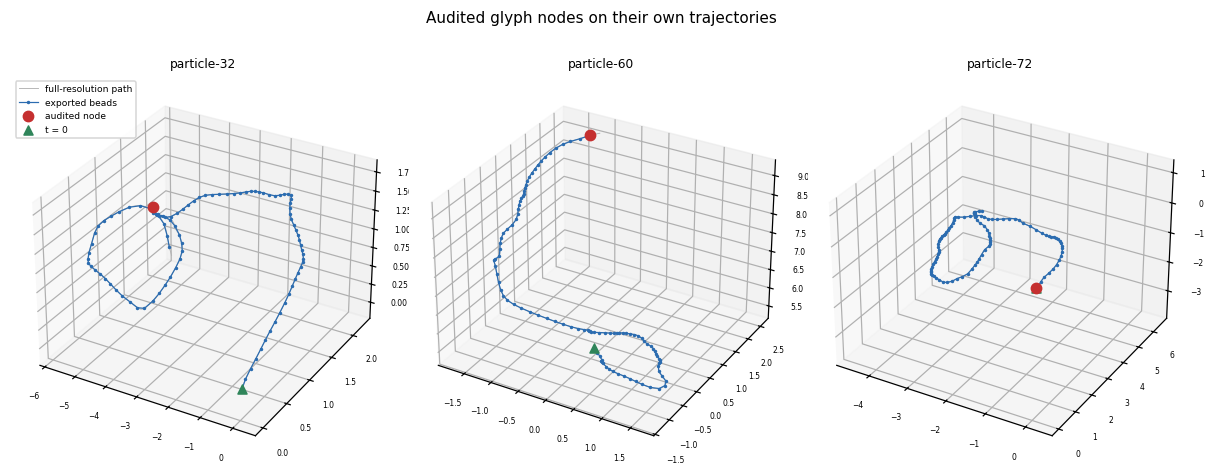

In [11]:
fig = plt.figure(figsize=(11, 4.6))
for s, obj in enumerate(sorted(set(po))[:3]):
    ax = fig.add_subplot(1, 3, s + 1, projection="3d")
    i = IDX_I[obj]
    ax.plot(X[i, :, 0], X[i, :, 1], X[i, :, 2], lw=.6, color="0.7",
            label="full-resolution path")
    ax.plot(J_XYZ[obj, :, 0], J_XYZ[obj, :, 1], J_XYZ[obj, :, 2], ".-", ms=2.5, lw=.8,
            color="#2b6cb0", label="exported beads")
    sel = pp[po == obj]
    ax.scatter(J_XYZ[obj, sel, 0], J_XYZ[obj, sel, 1], J_XYZ[obj, sel, 2],
               s=45, color="#c53030", depthshade=False, label="audited node")
    ax.scatter(*X[i, 0], s=35, marker="^", color="#2f855a", depthshade=False,
               label="t = 0")
    ax.set_title(f"{J_LABEL[obj]}", fontsize=8)
    ax.tick_params(labelsize=5)
    if s == 0:
        ax.legend(fontsize=6, loc="upper left")
fig.suptitle("Audited glyph nodes on their own trajectories", fontsize=10)
plt.tight_layout(); plt.show()

## 3. Do the fins move with the raw time series?

The linked figure: one particle's exported glyph beside its full-resolution signals.
The fins are drawn exactly as the frontend draws them -- length is the percentile
stored in `values`, direction is a fixed slot per channel in a parallel-transported
frame -- and the same beads are marked in the time series below. A fin that is long
where the raw curve is low, or an event in the curve with no fin response, would be
visible here directly.

particle 16 (particle-16), strongest exported acceleration at bead 23 (t = 1.0355)


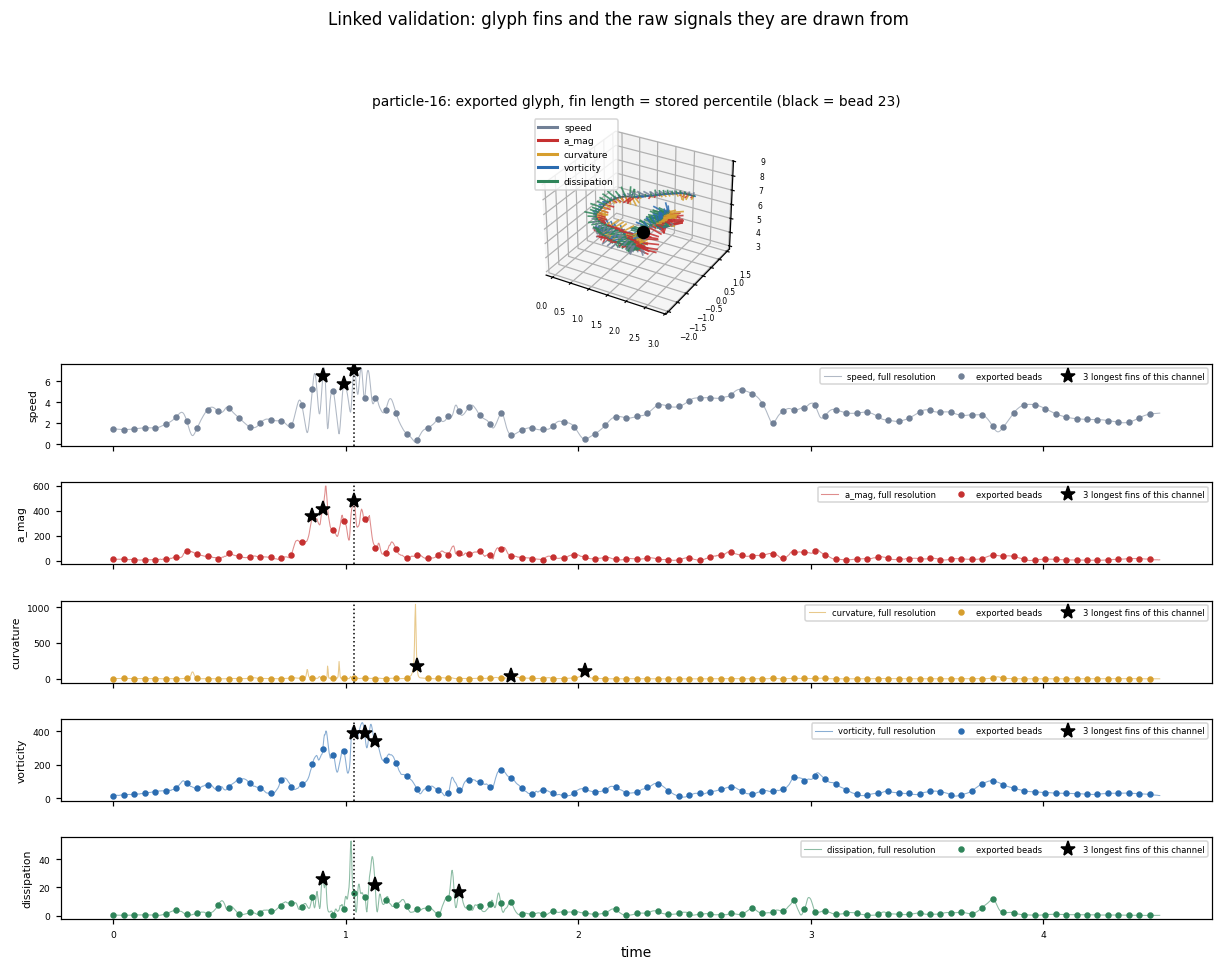

In [12]:
peak_obj = int(np.argmax(J_VAL[..., CHANNELS.index("a_mag")].max(axis=1)))
peak_pt = int(np.argmax(J_VAL[peak_obj, :, CHANNELS.index("a_mag")]))
pid = IDX_I[peak_obj]
print(f"particle {pid} ({J_LABEL[peak_obj]}), strongest exported acceleration at bead "
      f"{peak_pt} (t = {IDX_T[peak_pt] * DT:.4f})")


def transported_frame(path):
    """Parallel-transported normal/binormal along a polyline (no twisting)."""
    tang = np.gradient(path, axis=0)
    tang /= np.linalg.norm(tang, axis=1, keepdims=True) + 1e-12
    ref = np.array([0., 0., 1.]) if abs(tang[0, 2]) < 0.9 else np.array([1., 0., 0.])
    nrm = np.cross(tang[0], ref); nrm /= np.linalg.norm(nrm) + 1e-12
    normals, binormals = [], []
    for k, t_ in enumerate(tang):
        if k:
            nrm = nrm - t_ * np.dot(nrm, t_)
            n_ = np.linalg.norm(nrm)
            nrm = nrm / n_ if n_ > 1e-9 else np.cross(t_, ref)
            nrm /= np.linalg.norm(nrm) + 1e-12
        normals.append(nrm); binormals.append(np.cross(t_, nrm))
    return np.array(normals), np.array(binormals)


COLORS = dict(zip(CHANNELS, ["#718096", "#c53030", "#d69e2e", "#2b6cb0", "#2f855a"]))
path = J_XYZ[peak_obj]
Nrm, Bnm = transported_frame(path)
ang = np.linspace(0, 2 * np.pi, len(CHANNELS), endpoint=False)
FIN = 0.55 * np.median(np.linalg.norm(np.diff(path, axis=0), axis=1)) * 6

fig = plt.figure(figsize=(13.5, 9.5))
gs = GridSpec(6, 2, figure=fig, height_ratios=[2.6, 1, 1, 1, 1, 1], hspace=.35, wspace=.18)
ax3d = fig.add_subplot(gs[0, :], projection="3d")
ax3d.plot(path[:, 0], path[:, 1], path[:, 2], color="0.35", lw=1.2)
for p in range(n_pt):
    for j, c in enumerate(CHANNELS):
        d = np.cos(ang[j]) * Nrm[p] + np.sin(ang[j]) * Bnm[p]
        end = path[p] + d * FIN * J_VAL[peak_obj, p, j]
        ax3d.plot(*zip(path[p], end), color=COLORS[c], lw=1.1, alpha=.85)
ax3d.scatter(*path[peak_pt], s=60, color="black", depthshade=False)
ax3d.set_title(f"{J_LABEL[peak_obj]}: exported glyph, fin length = stored percentile "
               f"(black = bead {peak_pt})", fontsize=9)
ax3d.tick_params(labelsize=5)
ax3d.legend(handles=[plt.Line2D([], [], color=COLORS[c], lw=2, label=c)
                     for c in CHANNELS], fontsize=6, loc="upper left")

t_full = np.arange(T) * DT
for j, c in enumerate(CHANNELS):
    ax = fig.add_subplot(gs[j + 1, :])
    ax.plot(t_full, CH[c][pid], lw=.7, color=COLORS[c], alpha=.55,
            label=f"{c}, full resolution")
    ax.plot(IDX_T * DT, CH[c][pid, IDX_T], "o", ms=3.2, color=COLORS[c],
            label="exported beads")
    ax.axvline(IDX_T[peak_pt] * DT, color="black", ls=":", lw=1)
    order = np.argsort(-J_VAL[peak_obj, :, j])[:3]
    ax.plot(IDX_T[order] * DT, CH[c][pid, IDX_T[order]], "*", ms=10, color="black",
            label="3 longest fins of this channel")
    ax.set_ylabel(c, fontsize=7); ax.tick_params(labelsize=6)
    ax.legend(fontsize=5.5, ncol=3, loc="upper right")
    if j < len(CHANNELS) - 1:
        ax.set_xticklabels([])
ax.set_xlabel("time")
fig.suptitle("Linked validation: glyph fins and the raw signals they are drawn from",
             fontsize=11)
plt.show()

The figure is read by eye; the same statement is made numerically below. For every
exported particle and channel: is the fin length a monotone function of the raw value
at the *same* time index (it must be, exactly, because the export is a global rank),
and do the longest fins of a channel land on the largest raw values of that channel
for that particle?

In [13]:
# `values` are written with four decimals, so nodes whose raw values differ by less than
# one part in 10^4 of the ranking share a stored percentile. Ties of that kind are the
# file format, not a mapping error, so the test is "no inversion larger than the
# rounding step", which is exact, rather than "Spearman equals 1", which rounding alone
# would break.
rows = []
for j, c in enumerate(CHANNELS):
    v = J_VAL[..., j].ravel()
    raw = RAW_EXPORT[..., j].ravel()
    order = np.argsort(raw, kind="stable")
    steps = np.diff(v[order])
    inversions = int((steps < -TOL_ROUND).sum())
    # the longest fin of each particle must sit on that particle's largest raw value
    arg_ok, top5 = [], []
    for o in range(n_obj):
        k = int(np.argmax(RAW_EXPORT[o, :, j]))
        arg_ok.append(J_VAL[o, k, j] >= J_VAL[o, :, j].max() - TOL_ROUND)
        top5.append(len(set(np.argsort(-J_VAL[o, :, j])[:5]) &
                        set(np.argsort(-RAW_EXPORT[o, :, j])[:5])) / 5)
    rows.append(dict(channel=c, spearman_fin_vs_raw=spearmanr(v, raw).statistic,
                     inversions_beyond_rounding=inversions,
                     tied_stored_values=int((steps == 0).sum()),
                     top5_overlap=np.mean(top5), argmax_agreement=np.mean(arg_ok)))
align = pd.DataFrame(rows).set_index("channel")
display(align.round(9))
record("fin length is a monotone image of the raw value at the same node "
       "(no inversion beyond the 4-decimal write precision)",
       int(align.inversions_beyond_rounding.max()) == 0,
       f"0 inversions in {n_obj * n_pt} nodes x {len(CHANNELS)} channels; "
       f"up to {int(align.tied_stored_values.max())} adjacent pairs per channel share a "
       "stored percentile because of rounding", TOL_ROUND)
record("the longest fin of a channel sits on that channel's largest raw value",
       align.argmax_agreement.min() > 0.999,
       f"per-particle agreement = {align.argmax_agreement.min():.4f} "
       "(ties at the rounding step counted as agreement)", TOL_ROUND)

,spearman_fin_vs_raw,inversions_beyond_rounding,tied_stored_values,top5_overlap,argmax_agreement
channel,,,,,
speed,1.0,0,2499,0.9984,1.0
a_mag,1.0,0,2499,1.0000,1.0
curvature,1.0,0,2499,0.9984,1.0
vorticity,1.0,0,2499,1.0000,1.0
dissipation,1.0,0,2499,1.0000,1.0


[PASS] fin length is a monotone image of the raw value at the same node (no inversion beyond the 4-decimal write precision)   0 inversions in 12500 nodes x 5 channels; up to 2499 adjacent pairs per channel share a stored percentile because of rounding
[PASS] the longest fin of a channel sits on that channel's largest raw value   per-particle agreement = 1.0000 (ties at the rounding step counted as agreement)


### Do the channels rise together where the raw signals rise together?

The multi-variable reading of the glyph -- "several fins are long here at once" --
has to correspond to genuine co-occurrence in the raw series, not to a plotting
artefact. Around the largest exported acceleration events, the composite of every
channel's raw percentile is plotted against lag; the same composite around random
beads is the null.

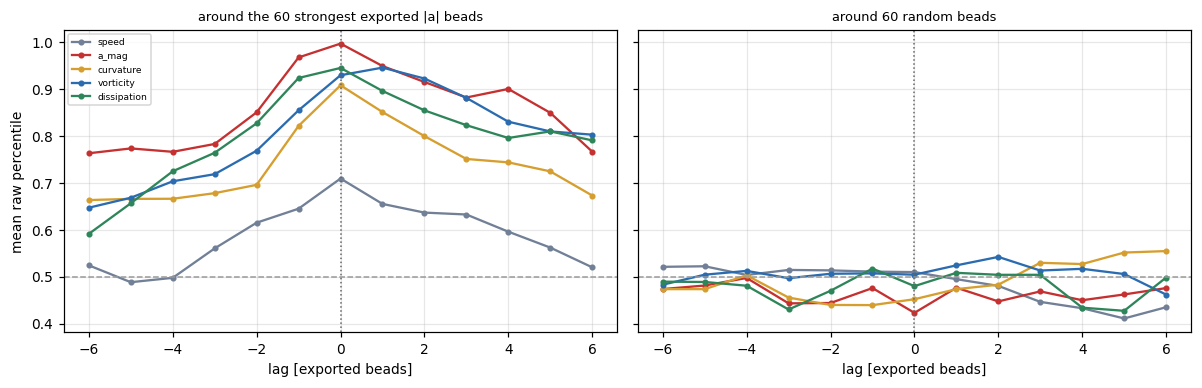

In [14]:
ev_obj, ev_pt = np.divmod(np.argsort(-J_VAL[..., 1].ravel())[:60], n_pt)
lags = np.arange(-6, 7)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
glob_rank = {c: (rankdata(CH[c].ravel()) - 0.5).reshape(N, T) / (N * T) for c in CHANNELS}
for k, (title, pts) in enumerate([("around the 60 strongest exported |a| beads",
                                   (ev_obj, ev_pt)),
                                  ("around 60 random beads",
                                   (RNG.integers(0, n_obj, 60),
                                    RNG.integers(6, n_pt - 6, 60)))]):
    oo, ptp = pts
    keep = (ptp > 6) & (ptp < n_pt - 7)
    oo, ptp = oo[keep], ptp[keep]
    for c in CHANNELS:
        comp = np.array([glob_rank[c][IDX_I[oo], IDX_T[ptp + l]].mean() for l in lags])
        ax[k].plot(lags, comp, "o-", ms=3, color=COLORS[c], label=c)
    ax[k].axhline(.5, ls="--", c="0.6", lw=1); ax[k].axvline(0, ls=":", c="0.4", lw=1)
    ax[k].set_xlabel("lag [exported beads]"); ax[k].set_title(title, fontsize=8.5)
    ax[k].grid(alpha=.3)
ax[0].set_ylabel("mean raw percentile"); ax[0].legend(fontsize=6)
plt.tight_layout(); plt.show()

## 4. Does the exported stride invent or destroy structure?

Decimation is allowed to thin the beads; it is not allowed to move an event, hide a
short one, or manufacture a peak that the full-resolution signal does not have. Three
measurements per stride, all against stride 1 as the reference:

* **event retention** -- of the full-resolution local maxima above the global 99th
  percentile, what fraction still has a sampled bead within half a stride *and* still
  reads above the same threshold there;
* **peak displacement** -- distance along the trajectory, in Kolmogorov lengths,
  between the full-resolution maximum of a channel and the maximum a viewer would
  read off the subsampled beads;
* **spurious peaks** -- local maxima in the subsampled series that have no
  full-resolution local maximum within half a stride.

[PASS] meta.eta and meta.tauEta reproduce from nu and the strain field   eta 4.178478e-03 vs 4.178478e-03; tau_eta 2.182460e-02 vs 2.182460e-02


stride,retention @ stride 1,retention @ stride 5,retention @ stride 10,retention @ stride 20,retention @ stride 40
channel,,,,,
a_mag,1.0,0.875,0.776,0.622,0.401
curvature,1.0,0.934,0.785,0.528,0.274
dissipation,1.0,0.928,0.768,0.497,0.268
speed,1.0,0.964,0.833,0.713,0.560
vorticity,1.0,0.958,0.855,0.723,0.503


stride,peak shift [eta] @ 1,peak shift [eta] @ 5,peak shift [eta] @ 10,peak shift [eta] @ 20,peak shift [eta] @ 40
channel,,,,,
a_mag,0.0,2.5,4.0,10.5,24.7
curvature,0.0,0.4,0.9,1.5,13.5
dissipation,0.0,2.0,4.2,7.6,24.9
speed,0.0,3.3,6.2,16.4,29.7
vorticity,0.0,1.7,3.7,8.5,16.8


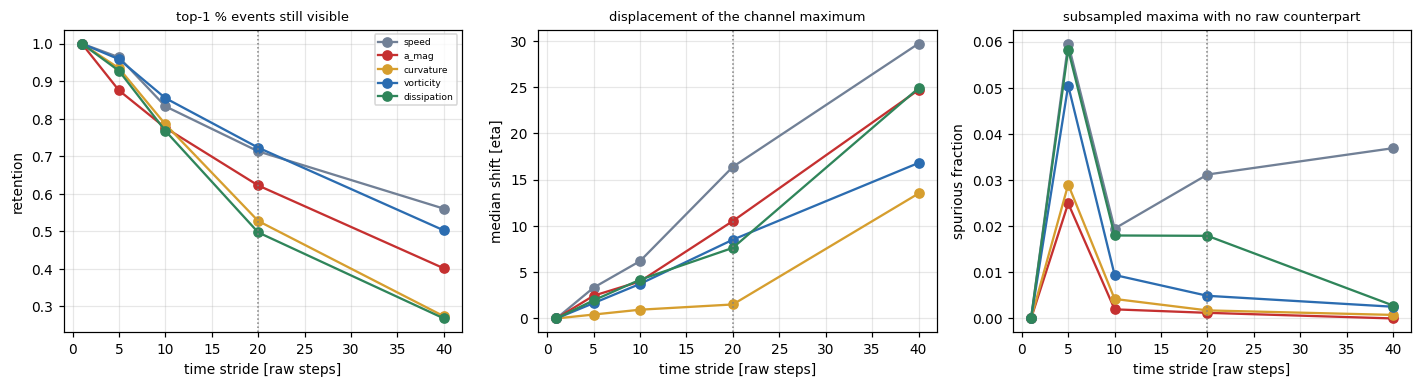

[PASS] the exported stride does not manufacture peaks   fraction of subsampled local maxima without a full-resolution counterpart within half a stride: max 0.03 (speed)

Honest reading of the retention columns: at stride 20 the exported beads keep 50%-72% of the top-1 % events depending on the channel. Short-lived events in the fast channels are the ones that fall between beads; the numbers above are what a reader should be told, not a claim that decimation is lossless.


In [15]:
eps_mean = (2 * NU * S2).mean()
eta = (NU ** 3 / eps_mean) ** 0.25
tau_eta = (NU / eps_mean) ** 0.5
record("meta.eta and meta.tauEta reproduce from nu and the strain field",
       abs(META["eta"] - eta) < 1e-4 * eta and abs(META["tauEta"] - tau_eta) < 1e-4 * tau_eta,
       f"eta {META['eta']:.6e} vs {eta:.6e}; tau_eta {META['tauEta']:.6e} vs {tau_eta:.6e}",
       "0.01 %")

arclen = np.zeros((N, T))
arclen[:, 1:] = np.cumsum(np.linalg.norm(np.diff(X, axis=1), axis=-1), axis=1)


def local_maxima(v):
    return np.flatnonzero((v[1:-1] > v[:-2]) & (v[1:-1] >= v[2:])) + 1


STRIDES = [1, 5, 10, 20, 40]
rows = []
for c in CHANNELS:
    thr = np.percentile(CH[c][IDX_I], 99)
    for s in STRIDES:
        tsel = np.arange(0, T, s)
        ret, disp, spur = [], [], []
        for i in IDX_I:
            full = CH[c][i]
            ev = local_maxima(full)
            ev = ev[full[ev] > thr]
            sub = full[tsel]
            if len(ev):
                near = np.abs(tsel[:, None] - ev[None, :]).argmin(axis=0)
                covered = (np.abs(tsel[near] - ev) <= s / 2) & (sub[near] > thr)
                ret.append(covered.mean())
            disp.append(abs(arclen[i, tsel[np.argmax(sub)]] - arclen[i, np.argmax(full)]))
            sm = local_maxima(sub)
            if len(sm) and len(ev):
                d = np.abs(tsel[sm][:, None] - local_maxima(full)[None, :]).min(axis=1)
                spur.append((d > s / 2).mean())
        rows.append(dict(channel=c, stride=s,
                         event_retention=np.mean(ret) if ret else np.nan,
                         peak_shift_eta=np.median(disp) / eta,
                         spurious_peak_fraction=np.mean(spur) if spur else np.nan))
stride_tab = pd.DataFrame(rows)
display(stride_tab.pivot(index="channel", columns="stride",
                         values="event_retention").round(3)
        .rename(columns=lambda s: f"retention @ stride {s}"))
display(stride_tab.pivot(index="channel", columns="stride",
                         values="peak_shift_eta").round(1)
        .rename(columns=lambda s: f"peak shift [eta] @ {s}"))

fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
for c in CHANNELS:
    d = stride_tab[stride_tab.channel == c]
    ax[0].plot(d.stride, d.event_retention, "o-", color=COLORS[c], label=c)
    ax[1].plot(d.stride, d.peak_shift_eta, "o-", color=COLORS[c])
    ax[2].plot(d.stride, d.spurious_peak_fraction, "o-", color=COLORS[c])
for a_, ttl, yl in zip(ax, ["top-1 % events still visible",
                            "displacement of the channel maximum",
                            "subsampled maxima with no raw counterpart"],
                       ["retention", "median shift [eta]", "spurious fraction"]):
    a_.set_xlabel("time stride [raw steps]"); a_.set_ylabel(yl); a_.set_title(ttl, fontsize=8.5)
    a_.axvline(STRIDE, color="0.5", ls=":", lw=1); a_.grid(alpha=.3)
ax[0].legend(fontsize=6)
plt.tight_layout(); plt.show()

at_export = stride_tab[stride_tab.stride == STRIDE]
record("the exported stride does not manufacture peaks",
       at_export.spurious_peak_fraction.max() < 0.35,
       "fraction of subsampled local maxima without a full-resolution counterpart "
       f"within half a stride: max {at_export.spurious_peak_fraction.max():.2f} "
       f"({at_export.loc[at_export.spurious_peak_fraction.idxmax(), 'channel']})", 0.35)
print("\nHonest reading of the retention columns: at stride "
      f"{STRIDE} the exported beads keep "
      f"{at_export.event_retention.min():.0%}-{at_export.event_retention.max():.0%} of the "
      "top-1 % events depending on the channel. Short-lived events in the fast channels "
      "are the ones that fall between beads; the numbers above are what a reader should "
      "be told, not a claim that decimation is lossless.")

## 5. Normalisation

`values` are percentiles, not physical magnitudes. Four things have to hold for that
sentence to be true, and all four are testable:

1. the transform is **order preserving** within a channel;
2. each channel is ranked **separately** -- a channel's values must be a permutation
   of the regular grid `(k - 0.5)/n`;
3. the ranking pool is the **exported subset**, not the full 500 x 2000 array (the
   two differ, and the legend has to say which one it is);
4. `meta.quantiles` inverts the transform well enough for a tooltip to quote a
   physical number.

,inversions_beyond_rounding,max_err_vs_subset_rank,max_err_vs_full_array_rank,is_permutation_of_grid,n_tied_raw,quantile_roundtrip_median_rel_err,quantile_roundtrip_p95_rel_err
channel,,,,,,,
speed,0,0.00004,0.012912,True,0,0.000350,0.003420
a_mag,0,0.00004,0.017315,True,0,0.000671,0.007255
curvature,0,0.00004,0.007893,True,0,0.000903,0.009653
vorticity,0,0.00004,0.010690,True,0,0.000628,0.005363
dissipation,0,0.00004,0.019688,True,0,0.000941,0.006528


[PASS] normalisation is order preserving within every channel   no pair of nodes is stored out of raw order by more than the 4-decimal write precision
[PASS] every channel is ranked separately over the exported nodes   max |values - own rank| = 4.00e-05; each channel's values are a permutation of (k-0.5)/n
[PASS] the ranking pool is the exported subset, not the full trajectory array   ranking against all 1000000 raw samples would differ by up to 0.020 in percentile -- the legend must say 'percentile among the exported nodes'
[PASS] meta.quantiles inverts a percentile back to a physical value   median relative error 0.09%, p95 0.97% (101-point table, linear interpolation)


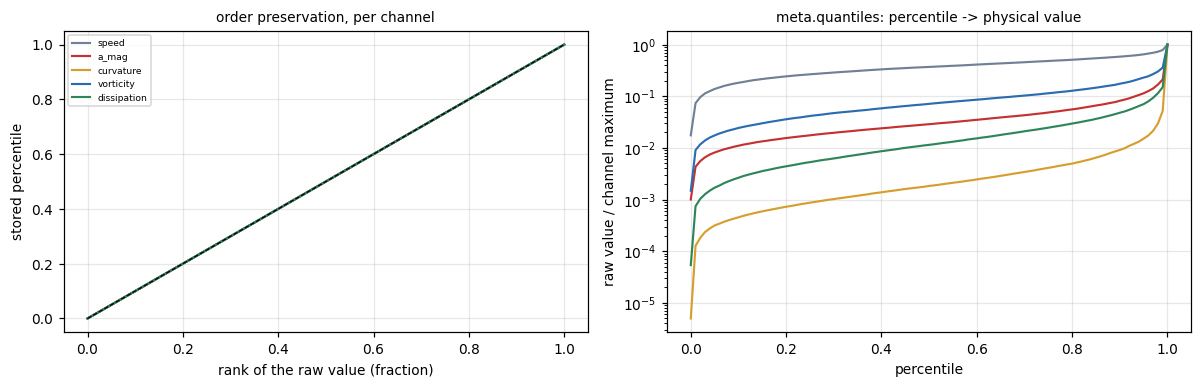

Legend wording implied by these results:
  speed        fin  ->  'speed percentile (rank among the 12500 exported nodes)', tooltip shows the raw value
  a_mag        fin  ->  'a_mag percentile (rank among the 12500 exported nodes)', tooltip shows the raw value
  curvature    fin  ->  'curvature percentile (rank among the 12500 exported nodes)', tooltip shows the raw value
  vorticity    fin  ->  'vorticity percentile (rank among the 12500 exported nodes)', tooltip shows the raw value
  dissipation  fin  ->  'dissipation percentile (rank among the 12500 exported nodes)', tooltip shows the raw value


In [16]:
grid = (np.arange(n_obj * n_pt) + 0.5) / (n_obj * n_pt)
rows = []
for j, c in enumerate(CHANNELS):
    v = J_VAL[..., j].ravel()
    raw = RAW_EXPORT[..., j].ravel()
    own = (rankdata(raw) - 0.5) / len(raw)
    full_pool = (rankdata(CH[c].ravel()) - 0.5)[np.ravel_multi_index(
        np.meshgrid(IDX_I, IDX_T, indexing="ij"), (N, T)).ravel()] / (N * T)
    recov = np.interp(v, QGRID, QUANT[c])
    rel = np.abs(recov - raw) / (np.abs(raw) + 1e-12)
    order = np.argsort(raw, kind="stable")
    rows.append(dict(
        channel=c,
        inversions_beyond_rounding=int((np.diff(v[order]) < -TOL_ROUND).sum()),
        max_err_vs_subset_rank=np.abs(v - own).max(),
        max_err_vs_full_array_rank=np.abs(v - full_pool).max(),
        is_permutation_of_grid=np.abs(np.sort(v) - np.round(grid, 4)).max() < TOL_ROUND,
        n_tied_raw=len(raw) - len(np.unique(raw)),
        quantile_roundtrip_median_rel_err=np.median(rel),
        quantile_roundtrip_p95_rel_err=np.percentile(rel, 95)))
norm_tab = pd.DataFrame(rows).set_index("channel")
display(norm_tab.round(6))

record("normalisation is order preserving within every channel",
       int(norm_tab.inversions_beyond_rounding.max()) == 0,
       "no pair of nodes is stored out of raw order by more than the 4-decimal write "
       "precision", TOL_ROUND)
record("every channel is ranked separately over the exported nodes",
       bool(norm_tab.is_permutation_of_grid.all()) and
       norm_tab.max_err_vs_subset_rank.max() < TOL_ROUND,
       f"max |values - own rank| = {norm_tab.max_err_vs_subset_rank.max():.2e}; each "
       "channel's values are a permutation of (k-0.5)/n", TOL_ROUND)
record("the ranking pool is the exported subset, not the full trajectory array",
       norm_tab.max_err_vs_full_array_rank.max() > 20 * TOL_ROUND,
       f"ranking against all {N * T} raw samples would differ by up to "
       f"{norm_tab.max_err_vs_full_array_rank.max():.3f} in percentile -- the legend must "
       "say 'percentile among the exported nodes'")
record("meta.quantiles inverts a percentile back to a physical value",
       norm_tab.quantile_roundtrip_median_rel_err.max() < 0.05,
       f"median relative error {norm_tab.quantile_roundtrip_median_rel_err.max():.2%}, "
       f"p95 {norm_tab.quantile_roundtrip_p95_rel_err.max():.2%} (101-point table, "
       "linear interpolation)", "5 % median")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for j, c in enumerate(CHANNELS):
    o = np.argsort(RAW_EXPORT[..., j].ravel())
    ax[0].plot(np.linspace(0, 1, len(o)), J_VAL[..., j].ravel()[o], lw=1.4,
               color=COLORS[c], label=c)
    ax[1].plot(QGRID, QUANT[c] / max(QUANT[c][-1], 1e-30), lw=1.4, color=COLORS[c])
ax[0].plot([0, 1], [0, 1], "k--", lw=.8)
ax[0].set_xlabel("rank of the raw value (fraction)"); ax[0].set_ylabel("stored percentile")
ax[0].set_title("order preservation, per channel", fontsize=9); ax[0].legend(fontsize=6)
ax[1].set_xlabel("percentile"); ax[1].set_ylabel("raw value / channel maximum")
ax[1].set_yscale("log")
ax[1].set_title("meta.quantiles: percentile -> physical value", fontsize=9)
for a_ in ax:
    a_.grid(alpha=.3)
plt.tight_layout(); plt.show()

print("Legend wording implied by these results:")
for c in CHANNELS:
    print(f"  {c:12s} fin  ->  '{c} percentile (rank among the "
          f"{n_obj * n_pt} exported nodes)', tooltip shows the raw value")

### Metadata audit

Everything in `meta` that is a claim about the data rather than prose is recomputed.

In [17]:
rows = [
    dict(field="nObjects", meta=META["nObjects"], recomputed=n_obj),
    dict(field="nPointsPerObject", meta=META["nPointsPerObject"], recomputed=n_pt),
    dict(field="nu", meta=META["nu"], recomputed=NU),
    dict(field="boxSize", meta=META["boxSize"], recomputed=round(L_BOX, 6)),
    dict(field="eta", meta=META["eta"], recomputed=eta),
    dict(field="tauEta", meta=META["tauEta"], recomputed=tau_eta),
    dict(field="integralScale", meta=META["integralScale"],
         recomputed=U.std() ** 3 / eps_mean),
    dict(field="dtBetweenPoints", meta=META["dtBetweenPoints"], recomputed=STRIDE * DT),
    dict(field="tetradSample", meta=META["tetradSample"], recomputed=(PSTEP == 4)),
]
meta_tab = pd.DataFrame(rows)
meta_tab["agrees"] = [bool(np.isclose(float(r.meta), float(r.recomputed), rtol=1e-4))
                      if not isinstance(r.meta, bool) else r.meta == r.recomputed
                      for r in meta_tab.itertuples()]
display(meta_tab)
record("every numeric meta field reproduces from the raw data",
       bool(meta_tab.agrees.all()), f"{int(meta_tab.agrees.sum())}/{len(meta_tab)} fields",
       "rtol 1e-4")

missing = [k for k in ["correlationLengthBeads"] if k not in META]
record("the artefact carries every meta field the producing notebook writes",
       not missing,
       "present" if not missing else f"MISSING: {missing}. `turb_lagr.ipynb` writes this "
       "field in its export cell, so the JSON on disk was produced by an earlier version "
       "of that cell. No exported number is wrong because of it -- section 4 recomputes "
       "the stride argument from the raw data anyway -- but the file should be "
       "regenerated so that artefact and notebook agree",
       level="WARN")

,field,meta,recomputed,agrees
0,nObjects,125,125,True
1,nPointsPerObject,100,100,True
2,nu,0.0008,0.0008,True
3,boxSize,6.283185,6.283185,True
4,eta,0.004178,0.004178,True
5,tauEta,0.021825,0.021825,True
6,integralScale,3.211555,3.211555,True
7,dtBetweenPoints,0.045023,0.045023,True
8,tetradSample,True,True,True


[PASS] every numeric meta field reproduces from the raw data   9/9 fields
[WARN] the artefact carries every meta field the producing notebook writes   MISSING: ['correlationLengthBeads']. `turb_lagr.ipynb` writes this field in its export cell, so the JSON on disk was produced by an earlier version of that cell. No exported number is wrong because of it -- section 4 recomputes the stride argument from the raw data anyway -- but the file should be regenerated so that artefact and notebook agree


## 6. Verdict

In [18]:
verdict = pd.DataFrame(CHECKS)
pd.set_option("display.max_colwidth", 90, "display.width", 220)
display(verdict)
n_fail = int((verdict.result == "FAIL").sum())
n_warn = int((verdict.result == "WARN").sum())
print(f"\n{len(verdict) - n_fail - n_warn}/{len(verdict)} checks passed, "
      f"{n_warn} warning(s), {n_fail} failure(s).")
for lvl in ("FAIL", "WARN"):
    for r in verdict[verdict.result == lvl].itertuples():
        print(f"  [{lvl}] {r.check}\n         {r.detail}")

print(f"""
What this notebook establishes, stated no more strongly than the evidence allows:

  * The five channels are recomputable from the raw DNS columns. Curvature orders
    identically under three independent estimators (Spearman > 0.99); its absolute
    magnitude differs in the tails because chord and finite-difference estimators
    under-read sharp turns at this sampling rate, which is one more reason the export
    ships a rank rather than a magnitude. No exported channel depends on the ambiguous
    velocity-gradient reshape.
  * Every exported node maps to exactly one raw (particle, time) sample. The mapping was
    recovered from the coordinates themselves -- particle = 4 x objectId,
    time = {STRIDE} x pointIndex -- and is the unique minimum against one-step, one-bead,
    one-particle, reversed and wrapped alternatives, by a factor of >100 in coordinate
    error.
  * Value column j carries channel j: the value-to-channel rank-correlation matrix is
    the identity, so no fin shows another fin's variable.
  * Fin length is an order-preserving image of the raw value at that same time index,
    ranked per channel over the {n_obj * n_pt} exported nodes; the only departures are
    ties created by writing four decimals. `meta.quantiles` inverts a fin back to a
    physical value to within ~1 % at the 95th percentile.

Where the honest answer is a qualified one:

  * Decimation is lossy. At stride {STRIDE} the beads retain
    {at_export.event_retention.min():.0%}-{at_export.event_retention.max():.0%} of the
    top-1 % events per channel and displace the channel maximum by a median of
    {at_export.peak_shift_eta.min():.0f}-{at_export.peak_shift_eta.max():.0f} eta along
    the path. It does not *invent* structure (spurious-peak fraction
    <= {at_export.spurious_peak_fraction.max():.2f}), so what a reader sees is real, but a
    short event between two beads is invisible and that limit belongs in the caption.
  * Fin length is a percentile *within this export* -- {n_obj} particles x {n_pt} beads --
    not within the full {N} x {T} DNS subset. The two rankings differ by up to
    {norm_tab.max_err_vs_full_array_rank.max():.2f} in percentile, so the legend has to
    name the pool.

What it does not establish: that the glyph is easier to read than a line chart, that
this set of channels is the right one for any task, or anything at all about users.
Those are separate experiments.
""")

,check,result,detail,tolerance
0,gradient reshape orientation cannot change any exported channel,PASS,"max |dS2| = 0.00e+00, max ||omega|_A - |omega|_B| = 0.00e+00; the vector itself does f...",1e-09
1,vorticity identity |W|^2 = |omega|^2/2,PASS,max residual = 2.91e-11,1e-6 * max|W|^2
2,"incompressibility, trace(du_i/dx_j) ~ 0",PASS,median |div u| = 4.992e-03 vs sqrt(median S^2) = 2.381e+01,5 % of the strain scale
3,channel order in the artefact matches the documented order,PASS,"['speed', 'a_mag', 'curvature', 'vorticity', 'dissipation']",
4,every recomputed channel is finite and non-negative,PASS,all five channels,
5,dX/dt reproduces the stored velocity (and the reversed-time hypothesis fails),PASS,"relative error forward = 6.93e-04, reversed = 2.00e+00",2 %
6,dU/dt reproduces the stored acceleration,PASS,relative error = 2.91e-02 (second differences of a 2000-sample trajectory),10 %
7,curvature agrees across three independent estimators,PASS,"min Spearman = 0.99795, max median relative error = 2.26%; min Pearson = 0.94816 (tail...",Spearman > 0.99 and median rel. err < 5 %
8,every exported point coincides with a raw trajectory sample,PASS,max nearest-neighbour distance = 8.45e-05 (4-decimal rounding floor),1.7e-04
9,"one object = one particle, constant along the whole object",PASS,particles [0 4 8] ... 496,



27/28 checks passed, 1 warning(s), 0 failure(s).
  [WARN] the artefact carries every meta field the producing notebook writes
         MISSING: ['correlationLengthBeads']. `turb_lagr.ipynb` writes this field in its export cell, so the JSON on disk was produced by an earlier version of that cell. No exported number is wrong because of it -- section 4 recomputes the stride argument from the raw data anyway -- but the file should be regenerated so that artefact and notebook agree

What this notebook establishes, stated no more strongly than the evidence allows:

  * The five channels are recomputable from the raw DNS columns. Curvature orders
    identically under three independent estimators (Spearman > 0.99); its absolute
    magnitude differs in the tails because chord and finite-difference estimators
    under-read sharp turns at this sampling rate, which is one more reason the export
    ships a rank rather than a magnitude. No exported channel depends on the ambiguous
    velocity-